In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [5]:
import os
os.system("pip install mediapipe -q")
os.system("wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task")

import cv2
import numpy as np
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe import Image, ImageFormat

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.6 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [6]:
BASE = "/kaggle/input/datasets/glushko/rock-paper-scissors-dataset"

TRAIN_DIR = os.path.join(BASE, "train")
VAL_DIR   = os.path.join(BASE, "val")
TEST_DIR  = os.path.join(BASE, "test")

for name, path in [("train", TRAIN_DIR), ("val", VAL_DIR), ("test", TEST_DIR)]:
    exists = os.path.exists(path)
    print(f"{name}: {path} — {'OK' if exists else 'NOT FOUND'}")

train: /kaggle/input/datasets/glushko/rock-paper-scissors-dataset/train — OK
val: /kaggle/input/datasets/glushko/rock-paper-scissors-dataset/val — OK
test: /kaggle/input/datasets/glushko/rock-paper-scissors-dataset/test — OK


In [7]:
IMG_SIZE = (224, 224)
PADDING  = 40

base_options  = python.BaseOptions(model_asset_path='hand_landmarker.task')
options       = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1)
mp_landmarker = vision.HandLandmarker.create_from_options(options)

def crop_hand_from_image(img_path):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    mp_img  = Image(image_format=ImageFormat.SRGB, data=img_rgb)
    result  = mp_landmarker.detect(mp_img)
    if result.hand_landmarks:
        h, w = img_bgr.shape[:2]
        hand = result.hand_landmarks[0]
        xs = [lm.x * w for lm in hand]
        ys = [lm.y * h for lm in hand]
        x1 = max(0, int(min(xs)) - PADDING)
        y1 = max(0, int(min(ys)) - PADDING)
        x2 = min(w, int(max(xs)) + PADDING)
        y2 = min(h, int(max(ys)) + PADDING)
        crop = img_rgb[y1:y2, x1:x2]
        if crop.size > 0:
            return cv2.resize(crop, IMG_SIZE)
    return cv2.resize(img_rgb, IMG_SIZE)

print("MediaPipe ready")

MediaPipe ready


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1777754612.811330     153 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777754612.831679     155 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [8]:
def load_split(split_dir):
    X, y = [], []
    class_names = sorted([
        d for d in os.listdir(split_dir)
        if os.path.isdir(os.path.join(split_dir, d))
    ])
    for class_name in class_names:
        class_path = os.path.join(split_dir, class_name)
        files = [f for f in os.listdir(class_path) if not f.startswith(".")]
        success = 0
        for img_file in files:
            crop = crop_hand_from_image(os.path.join(class_path, img_file))
            if crop is not None:
                X.append(crop)
                y.append(class_name.lower())
                success += 1
        print(f"  [{os.path.basename(split_dir)}] {class_name}: {success}/{len(files)}")
    return np.array(X, dtype=np.uint8), np.array(y)


print("train...")
X_train_raw, y_train_raw = load_split(TRAIN_DIR)

print("val...")
X_val_raw, y_val_raw = load_split(VAL_DIR)

print("test...")
X_test_raw, y_test_raw = load_split(TEST_DIR)

class_names_sorted = sorted(set(y_train_raw))
print(f"\nClasses: {class_names_sorted}")
print(f"Train: {len(X_train_raw)} | Val: {len(X_val_raw)} | Test: {len(X_test_raw)}")

train...


W0000 00:00:1777754747.450930     153 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


  [train] paper: 362/362
  [train] rock: 329/329
  [train] scissors: 329/329
val...
  [val] paper: 267/267
  [val] rock: 269/269
  [val] scissors: 268/268
test...
  [test] paper: 176/176
  [test] rock: 188/188
  [test] scissors: 176/176

Classes: [np.str_('paper'), np.str_('rock'), np.str_('scissors')]
Train: 1020 | Val: 804 | Test: 540


In [9]:
def encode(y_raw):
    enc = np.array([class_names_sorted.index(lbl) for lbl in y_raw])
    cat = tf.keras.utils.to_categorical(enc, num_classes=3)
    return enc, cat

enc_train, y_train = encode(y_train_raw)
enc_val,   y_val   = encode(y_val_raw)
enc_test,  y_test  = encode(y_test_raw)

print("Labels encoded")

Labels encoded


In [10]:
aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=25,
    brightness_range=[0.5, 1.5],
    zoom_range=0.20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=15,
    fill_mode='nearest',
)
val_aug = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = aug.flow(X_train_raw, y_train, batch_size=32, shuffle=True)
val_gen   = val_aug.flow(X_val_raw, y_val,  batch_size=32, shuffle=False)

print("Generators ready")

Generators ready


In [ ]:
from tensorflow.keras.models import Sequential
base_model = EfficientNetB0(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)
base_model.trainable = False

model = Sequential([
    base_model,                     
    GlobalAveragePooling2D(),       
    BatchNormalization(),           
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')  
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Params: {model.count_params():,}")
model.summary()

I0000 00:00:1777755235.299311      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777755235.305265      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Params: 4,415,910


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,415,910 (16.85 MB)

 Trainable params: 363,779 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [13]:
print("=== Phase 1: Training head only ===")
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

=== Phase 1: Training head only ===
Epoch 1/5


I0000 00:00:1777755323.007846     237 service.cc:152] XLA service 0x7b38180296f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777755323.007888     237 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777755323.007892     237 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777755325.288339     237 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-02 20:55:32.491720: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 20:55:32.634845: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 20:55:32.975327: E external/local_xl

13/32 ━━━━━━━━━━━━━━━━━━━━ 6s 327ms/step - accuracy: 0.4120 - loss: 1.4833

2026-05-02 20:55:52.754348: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 20:55:52.896271: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 20:55:53.231002: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 20:55:53.371449: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 20:55:54.150983: E external/local_xla/xla/stream_

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 843ms/step - accuracy: 0.4983 - loss: 1.2563

2026-05-02 20:56:19.217033: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 20:56:19.351229: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 20:56:19.658321: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 20:56:19.799801: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 20:56:19.940049: E external/local_xla/xla/stream_

32/32 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.5014 - loss: 1.2478 - val_accuracy: 0.7761 - val_loss: 0.6678
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 380ms/step - accuracy: 0.7531 - loss: 0.6375 - val_accuracy: 0.8047 - val_loss: 0.5332
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 390ms/step - accuracy: 0.8191 - loss: 0.4524 - val_accuracy: 0.8507 - val_loss: 0.4568
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 389ms/step - accuracy: 0.8630 - loss: 0.3468 - val_accuracy: 0.8159 - val_loss: 0.4511
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 376ms/step - accuracy: 0.8976 - loss: 0.3355 - val_accuracy: 0.8582 - val_loss: 0.3591


In [15]:
print("=== Phase 2: Fine-tuning ===")
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint("/kaggle/working/rps_best.keras", save_best_only=True, verbose=1),
]

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,
    callbacks=callbacks
)

=== Phase 2: Fine-tuning ===
Epoch 1/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - accuracy: 0.8426 - loss: 0.3943
Epoch 1: val_loss improved from inf to 0.30140, saving model to /kaggle/working/rps_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.8432 - loss: 0.3926 - val_accuracy: 0.8794 - val_loss: 0.3014 - learning_rate: 1.0000e-04
Epoch 2/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.9131 - loss: 0.2216
Epoch 2: val_loss improved from 0.30140 to 0.27936, saving model to /kaggle/working/rps_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 398ms/step - accuracy: 0.9130 - loss: 0.2216 - val_accuracy: 0.8843 - val_loss: 0.2794 - learning_rate: 1.0000e-04
Epoch 3/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.9210 - loss: 0.2038
Epoch 3: val_loss improved from 0.27936 to 0.25313, saving model to /kaggle/working/rps_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 406ms/step - accuracy: 0.9212 - loss: 0.2042 - val_accuracy: 0.8980 - val_loss: 0.2531 - learning_ra

In [16]:
all_acc     = history1.history['accuracy']     + history2.history['accuracy']
all_val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
all_loss    = history1.history['loss']         + history2.history['loss']
all_val_los = history1.history['val_loss']     + history2.history['val_loss']
phase1_len  = len(history1.history['accuracy'])

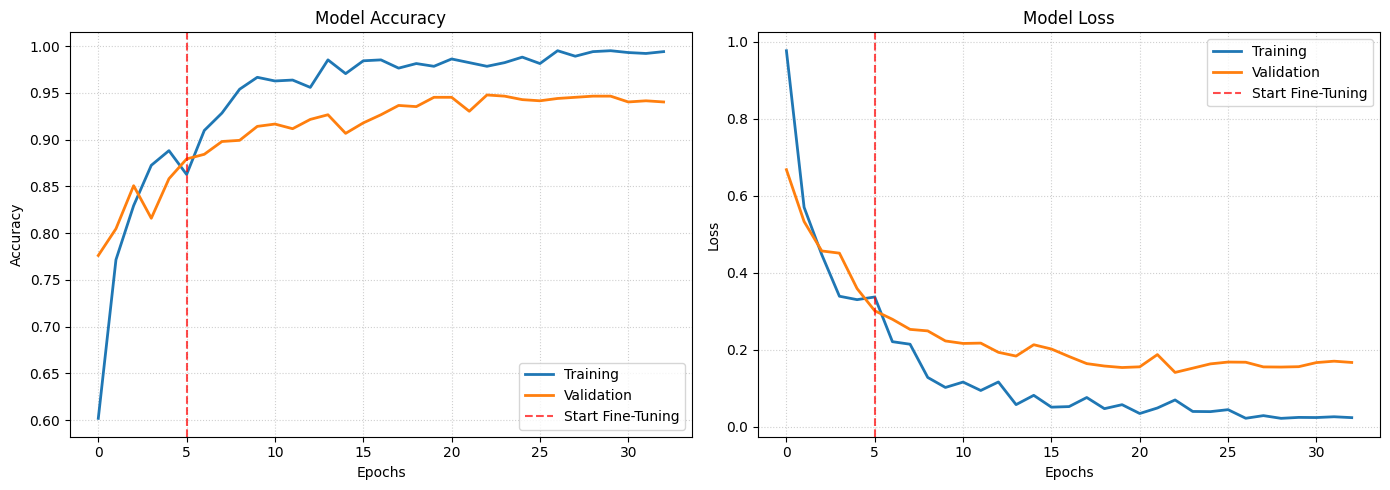

In [17]:
plt.figure(figsize=(14, 5)) 

plt.subplot(1, 2, 1)
plt.plot(all_acc, label='Training', linewidth=2)
plt.plot(all_val_acc, label='Validation', linewidth=2)
plt.axvline(x=phase1_len, color='red', linestyle='--', alpha=0.7, label='Start Fine-Tuning')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle=':', alpha=0.6) 
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(all_loss, label='Training', linewidth=2)
plt.plot(all_val_los, label='Validation', linewidth=2)
plt.axvline(x=phase1_len, color='red', linestyle='--', alpha=0.7, label='Start Fine-Tuning')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle=':', alpha=0.6) 
plt.legend()

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_premium.png", dpi=300) 
plt.show()

17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 434ms/step

Test Accuracy: 93.52%

Classification Report:
              precision    recall  f1-score   support

       paper       0.97      0.86      0.91       176
        rock       0.95      0.97      0.96       188
    scissors       0.90      0.98      0.93       176

    accuracy                           0.94       540
   macro avg       0.94      0.93      0.93       540
weighted avg       0.94      0.94      0.93       540



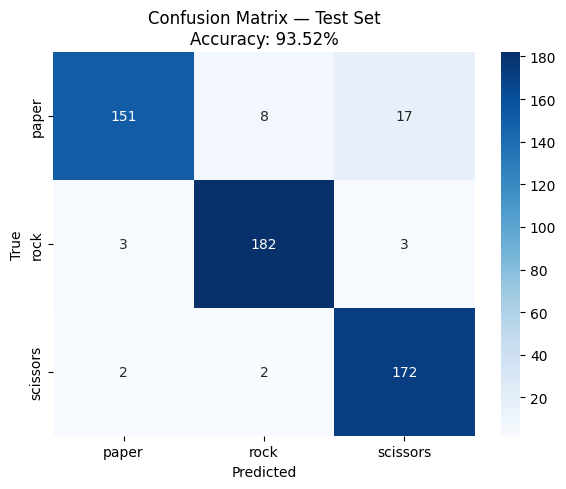

In [18]:
X_test_proc = preprocess_input(X_test_raw.copy().astype(np.float32))
y_pred      = np.argmax(model.predict(X_test_proc, batch_size=32, verbose=1), axis=1)
acc         = np.mean(y_pred == enc_test)

print(f"\nTest Accuracy: {acc:.2%}")
print("\nClassification Report:")
print(classification_report(enc_test, y_pred, target_names=class_names_sorted))

cm = confusion_matrix(enc_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_sorted, yticklabels=class_names_sorted)
plt.title(f"Confusion Matrix — Test Set\nAccuracy: {acc:.2%}")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png")
plt.show()

In [19]:
model.save("/kaggle/working/rps_final.keras")
with open("/kaggle/working/class_names.pkl", "wb") as f:
    pickle.dump(class_names_sorted, f)

print("Saved to /kaggle/working/")
print("  rps_final.keras")
print("  class_names.pkl")

Saved to /kaggle/working/
  rps_final.keras
  class_names.pkl
